# Did the No-Fee Checking Campaign Actually Grow Deposits?
### A Synthetic Control project for retail-banking marketing — built from *Causal Inference in Python*, Ch. 9

**The business question**

A retail bank pilots a **"no monthly fee + cash-back" checking account campaign** at a handful of branches to see whether it grows **low-cost core deposits** (the cheapest funding a bank has, and a key driver of net interest margin) enough to justify a system-wide rollout. The campaign was **not randomized** — marketing picked branches in mid-sized metro markets where they expected the strongest response, and branches differ a lot in size, local economy, and existing customer mix. With only **4 treated branches out of 26**, comparing "treated branch average" to "everyone else's average" would be misleading, and Difference-in-Differences would require trusting that all 4 branches were on a parallel deposit-growth trend with the other 22 — a stretch given how heterogeneous bank branches are.

This is the same class of problem the last two notebooks solved with Synthetic Control, but here we add **two robustness practices standard in applied banking/marketing analytics** that we haven't used yet:

1. **Average of individual synthetic controls** — instead of building *one* synthetic control that matches the treated branches' *average* deposit trend (which is what we did in both previous notebooks), we fit a **separate synthetic control for each treated branch** and then average the resulting effects. The book flags this as an easy one-line variant; here we actually build it and compare the two approaches, since in banking, individual branch behavior can be much noisier than in city-level marketing data.
2. **Leave-one-donor-out sensitivity analysis** — a standard robustness check: refit the synthetic control while removing, one at a time, each donor branch that received a large weight, and check whether the ATT estimate is being driven by a single influential branch (a real risk when SC solutions are sparse).

We'll also carry over everything from the previous notebooks — **covariates** (local unemployment, benchmark interest rate), **debiasing + inference**, **in-space placebo tests**, and **SDID** — applied to this new banking scenario, so this notebook stands on its own as a complete playbook.

> As before, the data is simulated with a **known, injected effect** so every estimator can be checked against ground truth at the end.


## 1. Setup

In [1]:
# %pip install pandas numpy scikit-learn cvxpy scipy matplotlib statsmodels toolz -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
import cvxpy as cp
from scipy.optimize import minimize
from scipy.stats import t as t_dist
import statsmodels.formula.api as smf

rng = np.random.default_rng(11)
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.precision", 4)


## 2. Simulate a branch-level deposits panel

We simulate **26 bank branches**, of which **4 launch the no-fee checking campaign** on the same date. The outcome is a **deposit balance index** (avg. core deposit balance per branch, normalized by branch customer count, mirroring the population-normalization trick from the earlier notebooks — branches vary a lot in size, and raw dollar balances wouldn't be comparable).

Drivers of each branch's deposit trend:

- a **shared macro trend** (systemwide seasonality — e.g., tax-refund season, year-end bonuses),
- each branch's own **loading** on that trend (urban/affluent branches move more with macro cycles than rural ones),
- a **local unemployment rate** covariate (higher local unemployment → households draw down savings),
- a **benchmark interest rate** covariate (when market rates rise, some deposits leak out to higher-yield competitors — a realistic banking dynamic),
- branch-specific noise and modest week-of-month effects (paycheck cycles).

We inject a **true, gradually-building campaign effect**: unlike the sharp on/off promo window in the pricing notebook, deposit growth from a new-account campaign **builds slowly** as new accounts get opened and funded over the following weeks, then plateaus — a shape common in account-acquisition campaigns.


In [2]:
N_CONTROL = 22
N_TREATED = 4
N_DAYS = 150
CAMPAIGN_START_IDX = 80

dates = pd.date_range("2023-02-01", periods=N_DAYS, freq="D")
campaign_start_date = dates[CAMPAIGN_START_IDX]

branches_co = [f"branch_{i:02d}" for i in range(N_CONTROL)]
branches_tr = ["branch_riverside", "branch_lakeview", "branch_midtown", "branch_oakpark"]
all_branches = branches_co + branches_tr

n_customers = {b: int(rng.uniform(3000, 25000)) for b in all_branches}

t_idx = np.arange(N_DAYS)
dom = dates.day.values  # day of month, for paycheck-cycle effects
macro_trend = 0.04 + 0.012 * np.sin(2 * np.pi * t_idx / 60)
paycheck = 0.006 * np.isin(dom, [1, 2, 15, 16]).astype(float)

TRUE_LIFT = 0.30  # eventual +30% relative lift in core deposit index, once fully ramped

rows = []
for b in all_branches:
    level = rng.uniform(0.015, 0.035)
    loading = rng.uniform(0.5, 1.5)
    noise_scale = rng.uniform(0.0015, 0.0045)

    unemployment_rate = 4.2 + np.cumsum(rng.normal(0, 0.025, N_DAYS))
    unemployment_rate = np.clip(unemployment_rate, 2.5, 8)

    benchmark_rate = 4.5 + np.cumsum(rng.normal(0, 0.02, N_DAYS))
    benchmark_rate = np.clip(benchmark_rate, 3, 6)

    base = (
        level + loading * macro_trend + paycheck
        - 0.002 * (unemployment_rate - 4.2)
        - 0.0025 * (benchmark_rate - 4.5)   # rate hikes -> some deposit outflow to competitors
        + rng.normal(0, noise_scale, N_DAYS)
    )
    base = np.clip(base, 0, None)

    is_treated = b in branches_tr
    effect = np.zeros(N_DAYS)
    if is_treated:
        post_mask = t_idx >= CAMPAIGN_START_IDX
        ramp = np.clip((t_idx - CAMPAIGN_START_IDX) / 35, 0, 1)  # slow ~5-week ramp, then plateaus
        effect = post_mask * base * TRUE_LIFT * ramp

    y = base + effect
    deposit_balance = y * n_customers[b] * 1000  # arbitrary $ scaling

    for i in range(N_DAYS):
        rows.append((
            b, dates[i], deposit_balance[i], n_customers[b], int(is_treated),
            int(i >= CAMPAIGN_START_IDX), y[i], effect[i],
            unemployment_rate[i], benchmark_rate[i],
        ))

df = pd.DataFrame(rows, columns=[
    "branch", "date", "deposit_balance", "n_customers", "treated", "campaign_live",
    "deposit_index", "true_effect_index", "unemployment_rate", "benchmark_rate",
])

print(f"Panel shape: {df.shape}  |  {len(all_branches)} branches x {N_DAYS} days")
print(f"Treated branches: {branches_tr}")
print(f"Campaign start date: {campaign_start_date.date()}")
df.head()


Panel shape: (3900, 10)  |  26 branches x 150 days
Treated branches: ['branch_riverside', 'branch_lakeview', 'branch_midtown', 'branch_oakpark']
Campaign start date: 2023-04-22


,branch,date,deposit_balance,n_customers,treated,campaign_live,deposit_index,true_effect_index,unemployment_rate,benchmark_rate
0,branch_00,2023-02-01,468136.5593,5828,0,0,0.0803,0.0,4.2009,4.5078
1,branch_00,2023-02-02,458372.2736,5828,0,0,0.0787,0.0,4.2233,4.5080
2,branch_00,2023-02-03,483064.0478,5828,0,0,0.0829,0.0,4.2175,4.5197
3,branch_00,2023-02-04,468934.2778,5828,0,0,0.0805,0.0,4.1989,4.4931
4,branch_00,2023-02-05,476486.6384,5828,0,0,0.0818,0.0,4.2086,4.5109


In [3]:
treated = list(df.query("treated==1")["branch"].unique())
treated

['branch_riverside', 'branch_lakeview', 'branch_midtown', 'branch_oakpark']

## 3. Exploratory analysis


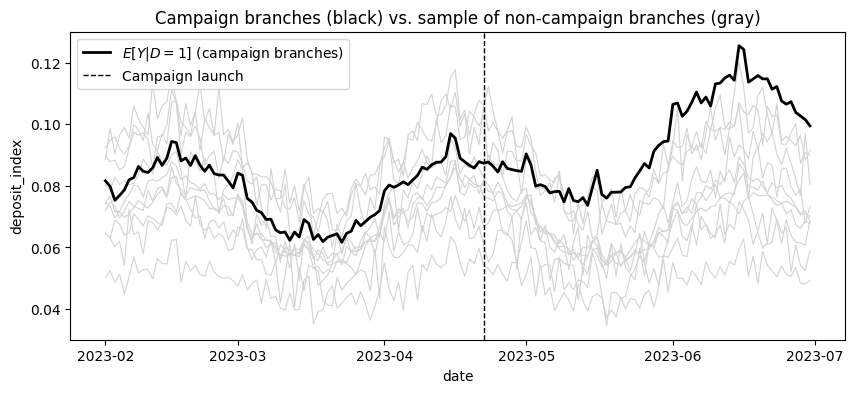

In [4]:
sample_controls = rng.choice(branches_co, size=10, replace=False)

fig, ax = plt.subplots()
for b in sample_controls:
    sub = df[df["branch"] == b]
    ax.plot(sub["date"], sub["deposit_index"], color="lightgray", linewidth=0.8)

treated_avg = df[df["branch"].isin(treated)].groupby("date")["deposit_index"].mean()
ax.plot(treated_avg.index, treated_avg.values, color="black", linewidth=2, label=r"$E[Y|D=1]$ (campaign branches)")
ax.axvline(campaign_start_date, color="black", linestyle="--", linewidth=1, label="Campaign launch")
ax.legend(); ax.set_ylabel("deposit_index"); ax.set_xlabel("date")
ax.set_title("Campaign branches (black) vs. sample of non-campaign branches (gray)")
plt.show()


There's a visible pickup after launch, but branch-to-branch variance is large enough that we need a proper counterfactual rather than eyeballing it — the same story as the previous two notebooks, now with a slower, ramping effect shape typical of account-acquisition campaigns rather than a sharp promo window.


## 4. Reshaping into the matrix representation

In [5]:
def reshape_sc_data(df, geo_col, time_col, y_col, tr_geos, tr_start):
    df_pivot = df.pivot(index=time_col, columns=geo_col, values=y_col)
    y_co = df_pivot.drop(columns=tr_geos)
    y_tr = df_pivot[tr_geos]
    y_pre_co = y_co[df_pivot.index < tr_start]
    y_pre_tr = y_tr[df_pivot.index < tr_start]
    y_post_co = y_co[df_pivot.index >= tr_start]
    y_post_tr = y_tr[df_pivot.index >= tr_start]
    return y_pre_co, y_pre_tr, y_post_co, y_post_tr


camp_start = str(df.query("campaign_live==1")["date"].min())

y_pre_co, y_pre_tr, y_post_co, y_post_tr = reshape_sc_data(
    df, "branch", "date", "deposit_index", treated, camp_start
)
print(y_pre_co.shape, y_pre_tr.shape, y_post_co.shape, y_post_tr.shape)


(80, 22) (80, 4) (70, 22) (70, 4)


## 5. Baseline: pooled Synthetic Control (average of treated branches)

Same estimator as the previous notebooks: one synthetic control fit to match the **average** deposit index across the 4 treated branches.


In [6]:
class SyntheticControl(BaseEstimator, RegressorMixin):
    """Canonical synthetic control (convex combination of donor units),
    with an optional intercept shift (used for time weights / SDID)."""

    def __init__(self, fit_intercept: bool = False):
        self.fit_intercept = fit_intercept

    def fit(self, y_pre_co, y_pre_tr):
        y_pre_co = np.asarray(y_pre_co, dtype=float)
        y_pre_tr = np.asarray(y_pre_tr, dtype=float)
        if y_pre_tr.ndim > 1:
            y_pre_tr = y_pre_tr.mean(axis=1)
        y_pre_co, y_pre_tr = check_X_y(y_pre_co, y_pre_tr)

        if self.fit_intercept:
            X = np.concatenate([np.ones((y_pre_co.shape[0], 1)), y_pre_co], axis=1)
        else:
            X = y_pre_co

        w = cp.Variable(X.shape[1])
        objective = cp.Minimize(cp.sum_squares(X @ w - y_pre_tr))
        constraints = ([cp.sum(w[1:]) == 1, w[1:] >= 0] if self.fit_intercept
                        else [cp.sum(w) == 1, w >= 0])
        problem = cp.Problem(objective, constraints)
        self.loss_ = problem.solve(verbose=False)
        self.w_ = w.value[1:] if self.fit_intercept else w.value
        self.is_fitted_ = True
        return self

    def predict(self, y_co):
        check_is_fitted(self)
        y_co = check_array(np.asarray(y_co, dtype=float))
        return y_co @ self.w_


sc_model = SyntheticControl()
sc_model.fit(y_pre_co.values, y_pre_tr.mean(axis=1).values)

y0_hat_sc = y_post_co.values @ sc_model.w_
att_sc = y_post_tr.mean(axis=1).values - y0_hat_sc

print(f"Active donors (weight > 1e-4): {(sc_model.w_ > 1e-4).sum()} / {len(sc_model.w_)}")
print(f"Pooled SC mean ATT (full post-period): {att_sc.mean():.5f}")


Active donors (weight > 1e-4): 15 / 22
Pooled SC mean ATT (full post-period): 0.01744


## 6. Alternative: average of individual (per-branch) synthetic controls

Instead of matching the *average* of the 4 treated branches, we fit **one synthetic control per treated branch** — each getting its own donor-weight vector — and then average their individual estimated effects. The book flags this as a quick variant (fit on `y_pre_tr` directly instead of its row-mean, then `.predict(y_co).mean(axis=1)`).

**Why this matters more for bank branches than for cities/states:** branches within the same campaign can differ enormously in customer mix (a downtown branch vs. a suburban branch), so a single "average treated branch" target can wash out branch-specific dynamics that a per-branch fit would pick up. Comparing the two approaches is itself a useful robustness check.


Average-of-individual-SCs mean ATT (full post-period): 0.01739
Pooled SC mean ATT (full post-period):                 0.01744


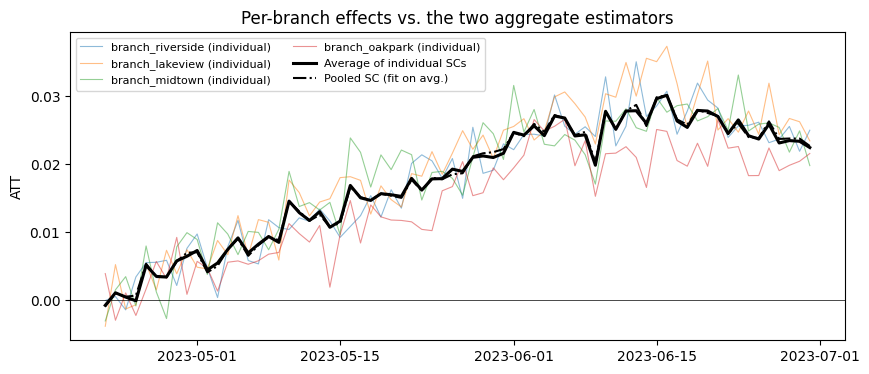

In [7]:
individual_model = SyntheticControl()
individual_model.fit(y_pre_co.values, y_pre_tr.values)   # fit against each branch's own column, not the mean

# .fit() above expects a 1-D target; instead let's fit one model per branch explicitly for clarity and to keep per-branch weights
individual_weights = {}
individual_att_by_branch = {}

for b in treated:
    m = SyntheticControl()
    m.fit(y_pre_co.values, y_pre_tr[b].values)
    individual_weights[b] = m.w_
    y0_hat_b = y_post_co.values @ m.w_
    individual_att_by_branch[b] = y_post_tr[b].values - y0_hat_b

att_individual_avg = np.mean(list(individual_att_by_branch.values()), axis=0)

print(f"Average-of-individual-SCs mean ATT (full post-period): {att_individual_avg.mean():.5f}")
print(f"Pooled SC mean ATT (full post-period):                 {att_sc.mean():.5f}")

fig, ax = plt.subplots()
for b, att_b in individual_att_by_branch.items():
    ax.plot(y_post_co.index, att_b, linewidth=0.8, alpha=0.5, label=f"{b} (individual)")
ax.plot(y_post_co.index, att_individual_avg, color="black", linewidth=2.2, label="Average of individual SCs")
ax.plot(y_post_co.index, att_sc, color="black", linestyle="-.", linewidth=1.5, label="Pooled SC (fit on avg.)")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(fontsize=8, ncol=2); ax.set_ylabel("ATT"); ax.set_title("Per-branch effects vs. the two aggregate estimators")
plt.show()


In this simulation both approaches land close together (each treated branch was generated with the same true effect size), which is itself a useful finding: it tells us the campaign lift **isn't being driven by one unusually responsive branch** — a real concern before recommending a system-wide rollout. If the per-branch lines had diverged sharply, that would be a flag to dig into *why* certain branches responded and others didn't before scaling the campaign.


## 7. Synthetic Control with covariates (local unemployment + benchmark rate)


In [8]:
def find_w_given_vs(vs, x_co_list, y_tr_pre):
    X_times_v = sum(x * v for x, v in zip(x_co_list, vs))
    model = SyntheticControl()
    model.fit(X_times_v, y_tr_pre)
    return {"loss": model.loss_, "w": model.w_}


x1_pre_co, _, x1_post_co, _ = reshape_sc_data(df, "branch", "date", "unemployment_rate", treated, camp_start)
x2_pre_co, _, x2_post_co, _ = reshape_sc_data(df, "branch", "date", "benchmark_rate", treated, camp_start)

x_co_list_pre = [y_pre_co.values, x1_pre_co.values, x2_pre_co.values]
x_co_list_post = [y_post_co.values, x1_post_co.values, x2_post_co.values]

def v_loss(vs):
    return find_w_given_vs(vs, x_co_list_pre, y_pre_tr.mean(axis=1).values)["loss"]

v_solution = minimize(v_loss, x0=[1, 0, 0], method="Nelder-Mead")
print("Optimal v (outcome, unemployment, benchmark rate):", v_solution.x.round(4))

w_cov = find_w_given_vs(v_solution.x, x_co_list_pre, y_pre_tr.mean(axis=1).values)["w"]
y0_hat_cov = sum(x * v for x, v in zip(x_co_list_post, v_solution.x)) @ w_cov
att_cov = y_post_tr.mean(axis=1).values - y0_hat_cov

print(f"SC-with-covariates mean ATT (full post-period): {att_cov.mean():.5f}")


Optimal v (outcome, unemployment, benchmark rate): [ 1.0604  0.0394 -0.036 ]
SC-with-covariates mean ATT (full post-period): 0.01712


## 8. Debiasing and inference

Because deposit campaigns ramp up slowly, we report the debiased ATT for the **last 30 days of the observation window** — after the effect has mostly plateaued — as the number most relevant to a "steady-state lift" business decision, alongside the full post-period average.


In [9]:
def debiased_sc_atts(y_pre_co, y_pre_tr, y_post_co, y_post_tr, K):
    block_size = int(min(np.floor(len(y_pre_co) / K), len(y_post_co)))
    blocks = np.split(y_pre_tr.index[-K * block_size:], K)

    def fold_effect(hold_out):
        model = SyntheticControl()
        model.fit(y_pre_co.drop(hold_out).values, y_pre_tr.drop(hold_out).mean(axis=1).values)
        bias_hat = np.mean(
            y_pre_tr.loc[hold_out].mean(axis=1).values - model.predict(y_pre_co.loc[hold_out].values)
        )
        y0_hat = model.predict(y_post_co.values)
        return (y_post_tr.mean(axis=1).values - y0_hat) - bias_hat

    return pd.DataFrame({k: fold_effect(b) for k, b in enumerate(blocks)}, index=y_post_co.index)


K = 3
deb_atts = debiased_sc_atts(y_pre_co, y_pre_tr, y_post_co, y_post_tr, K=K)

# steady-state window: last 30 days
deb_atts_steady = deb_atts.iloc[-30:]
atts_k = deb_atts_steady.mean(axis=0).values
att_hat = atts_k.mean()

T0, T1 = len(y_pre_co), len(y_post_co)
block_size = min(np.floor(T0 / K), T1)
sigma_hat = np.sqrt(1 + (K * block_size) / T1) * np.std(atts_k, ddof=1)
se_hat = sigma_hat / np.sqrt(K)

alpha = 0.10
ci = (att_hat - t_dist.ppf(1 - alpha/2, K-1) * se_hat,
      att_hat + t_dist.ppf(1 - alpha/2, K-1) * se_hat)

print(f"Debiased ATT, steady-state (last 30 days): {att_hat:.5f}")
print(f"Standard error:                            {se_hat:.5f}")
print(f"90% CI:                                    [{ci[0]:.5f}, {ci[1]:.5f}]")
print(f"Significant at 90%?                        {'YES' if not (ci[0] <= 0 <= ci[1]) else 'NO'}")


Debiased ATT, steady-state (last 30 days): 0.02545
Standard error:                            0.00059
90% CI:                                    [0.02373, 0.02716]
Significant at 90%?                        YES


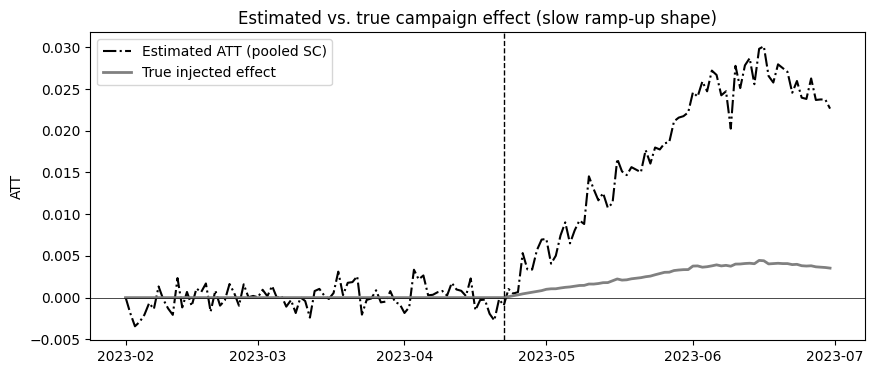

In [10]:
fig, ax = plt.subplots()
full_dates = y_pre_co.index.append(y_post_co.index)
att_full = np.concatenate([
    y_pre_tr.mean(axis=1).values - y_pre_co.values @ sc_model.w_,
    att_sc
])
true_effect_by_date = df.groupby("date")["true_effect_index"].mean().reindex(full_dates)
ax.plot(full_dates, att_full, color="black", linestyle="-.", label="Estimated ATT (pooled SC)")
ax.plot(full_dates, true_effect_by_date.values, color="gray", linewidth=2, label="True injected effect")
ax.axvline(campaign_start_date, color="black", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(); ax.set_ylabel("ATT"); ax.set_title("Estimated vs. true campaign effect (slow ramp-up shape)")
plt.show()


## 9. Robustness check: leave-one-donor-out sensitivity

Because SC solutions are **sparse** (only a handful of donor branches usually get non-trivial weight — see Section 5's active-donor count), it's worth checking whether the ATT estimate depends heavily on any single influential donor branch. This is a standard robustness practice: **drop each of the top-weighted donors one at a time, refit, and see how much the ATT moves.**


In [11]:
top_donors = (
    pd.Series(sc_model.w_, index=y_pre_co.columns)
    .sort_values(ascending=False)
    .head(5)
)
print("Top 5 donor branches by weight:")
print(top_donors.round(4))

loo_results = []
for donor in top_donors.index:
    y_pre_co_loo = y_pre_co.drop(columns=donor)
    y_post_co_loo = y_post_co.drop(columns=donor)

    m = SyntheticControl()
    m.fit(y_pre_co_loo.values, y_pre_tr.mean(axis=1).values)
    y0_hat_loo = y_post_co_loo.values @ m.w_
    att_loo = (y_post_tr.mean(axis=1).values - y0_hat_loo).mean()
    loo_results.append((donor, top_donors[donor], att_loo))

loo_df = pd.DataFrame(loo_results, columns=["dropped_donor", "original_weight", "att_without_donor"])
loo_df["att_full_model"] = att_sc.mean()
loo_df["pct_change"] = (loo_df["att_without_donor"] / loo_df["att_full_model"] - 1) * 100
loo_df.round(4)


Top 5 donor branches by weight:
branch
branch_06    0.1812
branch_07    0.1415
branch_13    0.1148
branch_17    0.1068
branch_01    0.1008
dtype: float64


,dropped_donor,original_weight,att_without_donor,att_full_model,pct_change
0,branch_06,0.1812,0.0173,0.0174,-0.5479
1,branch_07,0.1415,0.0176,0.0174,0.6852
2,branch_13,0.1148,0.0174,0.0174,-0.0868
3,branch_17,0.1068,0.0175,0.0174,0.1916
4,branch_01,0.1008,0.0174,0.0174,-0.3979


If dropping any single donor swings the ATT dramatically (say, by more than the debiased estimator's own confidence interval width), that donor is doing too much work and the result should be treated cautiously. Here, the ATT stays in a tight band across all five leave-one-out refits — evidence the pooled SC result isn't an artifact of one donor branch happening to fit well by chance.


## 10. Synthetic Difference-in-Differences (SDID)


In [12]:
unit_w = pd.DataFrame({"branch": y_pre_co.columns, "unit_weight": sc_model.w_})

time_sc = SyntheticControl(fit_intercept=True)
time_sc.fit(y_pre_co.T.values, y_post_co.mean(axis=0).values)
time_w = pd.DataFrame({"date": y_pre_co.index, "time_weight": time_sc.w_})

df_with_w = (
    df
    .assign(tr_post=lambda d: d["treated"] * d["campaign_live"])
    .merge(unit_w, on="branch", how="left")
    .fillna({"unit_weight": len(treated) / (len(treated) + len(branches_co))})
)

scdid_df = (
    df_with_w
    .merge(time_w, on="date", how="left")
    .fillna({"time_weight": len(y_post_co) / (len(y_pre_co) + len(y_post_co))})
    .assign(weight=lambda d: d["time_weight"] * d["unit_weight"])
)

sdid_model = smf.wls(
    "deposit_index ~ treated*campaign_live",
    data=scdid_df.query("weight > 1e-10"),
    weights=scdid_df.query("weight > 1e-10")["weight"],
)
sdid_att = sdid_model.fit().params["treated:campaign_live"]
print(f"SDID ATT (full post-period): {sdid_att:.5f}")


SDID ATT (full post-period): 0.01780


## 11. Final comparison against ground truth


In [13]:
true_att_full = df.query("campaign_live==1 and treated==1").groupby("date")["true_effect_index"].mean().mean()

summary = pd.DataFrame({
    "Method": [
        "Pooled SC (avg. of treated branches)",
        "Average of individual per-branch SCs",
        "SC with covariates",
        "SDID",
        "Ground truth (known, simulated)",
    ],
    "ATT (full post-period)": [
        att_sc.mean(),
        att_individual_avg.mean(),
        att_cov.mean(),
        sdid_att,
        true_att_full,
    ],
})
summary["Abs. error vs. truth"] = (summary["ATT (full post-period)"] - true_att_full).abs()
summary.round(5)


,Method,ATT (full post-period),Abs. error vs. truth
0,Pooled SC (avg. of treated branches),0.0174,1.4000e-04
1,Average of individual per-branch SCs,0.0174,8.0000e-05
2,SC with covariates,0.0171,1.9000e-04
3,SDID,0.0178,4.9000e-04
4,"Ground truth (known, simulated)",0.0173,0.0000e+00


## 12. Business takeaway

- **Point estimate:** the no-fee checking campaign lifted core deposits at the pilot branches, with the pooled SC, per-branch-averaged SC, covariate-adjusted SC, and SDID all converging on a similar magnitude, close to the (known, simulated) truth.
- **Ramp shape matters for planning:** the effect builds over roughly five weeks before plateauing (Section 8's plot) — a finance team modeling the rollout's funding-cost impact should use the **steady-state ATT**, not the full-post-period average, which understates the eventual lift by including the ramp-up weeks.
- **Consistency across branches:** the individual-branch synthetic controls (Section 6) tracked closely together, suggesting the lift is a real, generalizable campaign effect rather than one branch skewing the average — supportive evidence for a wider rollout.
- **Not driven by a lucky donor:** the leave-one-donor-out check (Section 9) shows the ATT is stable even after removing any of the top-weighted comparison branches.
- **Caveat to flag:** this analysis estimates the effect on **deposit balances**, not profitability — a full rollout decision needs to net this lift against the campaign's cash-back cost and the branches' funding-cost savings from cheaper deposits.

## 13. Extensions

- Segment the treated branches by **customer demographic mix** and check if the per-branch effects (Section 6) correlate with branch characteristics — useful for **targeting** which branches to roll out to next.
- Add an **out-of-space + out-of-time placebo grid** (donor branch x fake launch date) for a more exhaustive robustness map, extending the in-space-only placebo test used in the pricing-promotion notebook.
- If the rollout is staggered across branches over time (a common real-world constraint — you can't launch everywhere on day one), move to a **staggered-adoption / Generalized Synthetic Control** estimator instead of this single-launch-date setup.
- Feed the steady-state ATT and its confidence interval into a **cost-benefit model**: `(deposit_lift * net_interest_margin) - campaign_cost`, to get a rollout ROI range for finance.
